In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'


In [2]:
import os
import glob

data_dir = '/Users/harryclark/Downloads/COHORT12/xgboost_task_anchoring'
all_files = glob.glob(os.path.join(data_dir, "*.csv"))

data = pd.DataFrame()
for file in all_files:
    df = pd.read_csv(file)
    data = pd.concat([data, df], ignore_index=True)

print(f"Loaded {len(all_files)} files. Combined data shape: {data.shape}")

Loaded 22 files. Combined data shape: (3104028, 17)


In [13]:
data_trained

,Unnamed: 0,mouse,day,cluster_id,cluster_id_cov,trained_on,tested_on,n_neurons,pR2_cv,cluster_id_theta_index,cluster_id_cov_theta_index,firing_mode,n_filters,history_length,distance,position_in_covariate,grid_score_cov
8488,8488,25,21,108,112,NGS,GC,0,0.046864,0.432769,0.043491,TA,5,1000,55.217751,True,NaN
8489,8489,25,21,108,112,NGS,GC,0,-0.044866,0.432769,0.043491,TI,5,1000,55.217751,True,NaN
8491,8491,25,21,108,112,NGS,GC,1,-0.024535,0.432769,0.043491,TA,5,1000,55.217751,False,NaN
8492,8492,25,21,108,112,NGS,GC,1,-0.021821,0.432769,0.043491,TI,5,1000,55.217751,False,NaN
8494,8494,25,21,108,112,NGS,GC,1,0.021726,0.432769,0.043491,TA,5,1000,55.217751,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3104021,139493,21,25,325,339,NGS,NGS,0,NaN,0.021838,0.043331,TI,5,1000,90.000000,True,0.143329
3104023,139495,21,25,325,339,NGS,NGS,1,0.016037,0.021838,0.043331,TA,5,1000,90.000000,False,0.143329
3104024,139496,21,25,325,339,NGS,NGS,1,NaN,0.021838,0.043331,TI,5,1000,90.000000,False,0.143329
3104026,139498,21,25,325,339,NGS,NGS,1,0.033867,0.021838,0.043331,TA,5,1000,90.000000,True,0.143329


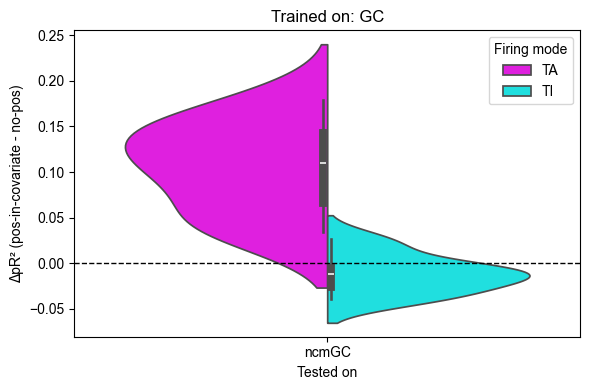

No data to plot for trained_on: NGS


<Figure size 600x400 with 0 Axes>

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Subset to only firing_modes of interest
data_sub = data[data['firing_mode'].isin(['TA', 'TI'])]

# Get all unique 'trained_on' groups
trained_on_groups = data_sub['trained_on'].unique()

for trained_on in trained_on_groups:
    data_trained = data_sub[data_sub['trained_on'] == trained_on]
    tested_on_groups = data_trained['tested_on'].unique()
    plt.figure(figsize=(6, 4))
    plot_data = []

    for tested_on in tested_on_groups:
        df_tested = data_trained[data_trained['tested_on'] == tested_on]
        grouped = df_tested[df_tested['n_neurons'] == 1].groupby(['mouse', 'day', 'cluster_id', 'firing_mode'])
        for name, group in grouped:
            # Ensure both position_in_covariate conditions are present (handle bool or int)
            pos_vals = set(group['position_in_covariate'].astype(int))
            if pos_vals == {0, 1}:
                pR2_pos = group[group['position_in_covariate'].astype(int) == 1]['pR2_cv'].values
                pR2_nopos = group[group['position_in_covariate'].astype(int) == 0]['pR2_cv'].values
                if len(pR2_pos) == 1 and len(pR2_nopos) == 1:
                    diff = pR2_pos[0] - pR2_nopos[0]
                    plot_data.append({
                        'tested_on': tested_on,
                        'firing_mode': name[3],  # name = (mouse, day, cluster_id, firing_mode)
                        'pR2_diff': diff
                    })

    plot_df = pd.DataFrame(plot_data)
    if not plot_df.empty and 'firing_mode' in plot_df.columns:
        plot_df = plot_df[plot_df['firing_mode'].isin(['TA', 'TI'])]

        sns.violinplot(
            data=plot_df,
            x='tested_on',
            y='pR2_diff',
            hue='firing_mode',
            split=True,
            palette={'TA': 'magenta', 'TI': 'cyan'},
            inner='box'
        )
        plt.axhline(0, color='k', linestyle='--', linewidth=1)
        plt.ylabel('ΔpR² (pos-in-covariate - no-pos)')
        plt.xlabel('Tested on')
        plt.title(f"Trained on: {trained_on}")
        plt.legend(title='Firing mode')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data to plot for trained_on: {trained_on}")